GPUs detected: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]
Mixed precision policy: <DTypePolicy "mixed_float16">
Loaded rows: 10250
Vocab sizes -> events: 21 source: 5 device: 10
Sequences built: (10218, 32) labels: (10218,)


Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ dt_seq (InputLayer) │ (None, 32)        │          0 │ -                 │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dt_norm (Lambda)    │ (None, 32)        │          0 │ dt_seq[0][0]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ event_ids           │ (None, 32)        │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ src_ids             │ (None, 32)        │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dev_ids             │ (None, 32)        │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dt_reshape          │ (None, 32, 1)     │          0 │ dt_norm[0][0]     │
│ (Reshape)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ event_emb           │ (None, 32, 64)    │      1,344 │ event_ids[0][0]   │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ src_emb (Embedding) │ (None, 32, 32)    │        160 │ src_ids[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dev_emb (Embedding) │ (None, 32, 32)    │        320 │ dev_ids[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dt_proj             │ (None, 32, 32)    │         64 │ dt_reshape[0][0]  │
│ (TimeDistributed)   │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate_1       │ (None, 32, 160)   │          0 │ event_emb[0][0],  │
│ (Concatenate)       │                   │            │ src_emb[0][0],    │
│                     │                   │            │ dev_emb[0][0],    │
│                     │                   │            │ dt_proj[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_1 (Conv1D)   │ (None, 32, 128)   │     61,568 │ concatenate_1[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_2 (Conv1D)   │ (None, 32, 64)    │     24,640 │ conv1d_1[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ maxpool_time        │ (None, 16, 64)    │          0 │ conv1d_2[0][0]    │
│ (MaxPooling1D)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv_proj           │ (None, 16, 64)    │      4,160 │ maxpool_time[0][… │
│ (TimeDistributed)   │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lstm_after_conv     │ (None, 128)       │     98,816 │ conv_proj[0][0]   │
│ (LSTM)              │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_5 (Dense)     │ (None, 256)       │     33,024 │ lstm_after_conv[… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_1 (Dropout) │ (None, 256)       │          0 │ dense_5[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ next_event_out      │ (None, 21)        │      5,397 │ dropout_1[0][0] 

 Total params: 229,493 (896.46 KB)

 Trainable params: 229,493 (896.46 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/12
64/64 ━━━━━━━━━━━━━━━━━━━━ 8s 36ms/step - loss: 2.9923 - sparse_categorical_accuracy: 0.0588 - val_loss: 2.9445 - val_sparse_categorical_accuracy: 0.0592 - learning_rate: 0.0010
Epoch 2/12
64/64 ━━━━━━━━━━━━━━━━━━━━ 1s 19ms/step - loss: 2.9445 - sparse_categorical_accuracy: 0.0634 - val_loss: 2.9296 - val_sparse_categorical_accuracy: 0.0729 - learning_rate: 0.0010
Epoch 3/12
64/64 ━━━━━━━━━━━━━━━━━━━━ 1s 20ms/step - loss: 2.9397 - sparse_categorical_accuracy: 0.0651 - val_loss: 2.9260 - val_sparse_categorical_accuracy: 0.0797 - learning_rate: 0.0010
Epoch 4/12
64/64 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - loss: 2.9405 - sparse_categorical_accuracy: 0.0641 - val_loss: 2.9277 - val_sparse_categorical_accuracy: 0.0797 - learning_rate: 0.0010
Epoch 5/12
64/64 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - loss: 2.9296 - sparse_categorical_accuracy: 0.0680 - val_loss: 2.9189 - val_sparse_categorical_accuracy: 0.0700 - learning_rate: 0.0010
Epoch 6/12
64/64 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - lo

<Figure size 1400x1200 with 0 Axes>

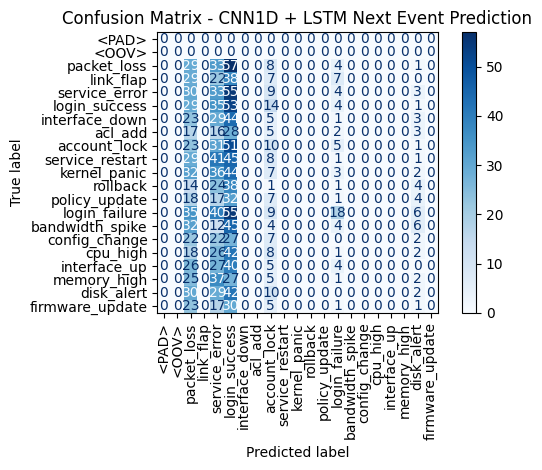

Saved confusion matrix to: /mnt/data/gpu_cnn1d_lstm_model/confusion_matrix_cnn1d_lstm.png
Model saved to: /mnt/data/gpu_cnn1d_lstm_model/cnn1d_lstm_final.keras
Training summary saved.


In [5]:
# GPU_CNN1D_LSTM_telemetry_FULL_with_fixed_CM.py
# CNN-1D + LSTM hybrid model for next-event prediction on synthetic telemetry.
# Includes: preprocessing, training, top-k accuracy, and FIXED confusion matrix plotting (always includes all classes).
#
# Requirements:
#   pip install tensorflow pandas numpy scikit-learn matplotlib
#
# Notes:
# - Uses mixed precision ONLY if GPU exists.
# - Fixed-length sliding windows => mask_zero=False in embeddings.
# - Saves model in native Keras format (.keras), saves vocabs, summary JSON, and confusion matrix PNG.

import os
import json
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import tensorflow as tf
from tensorflow.keras import layers, models, callbacks
from tensorflow.keras import mixed_precision

# ----------------- Hyperparams -----------------
CSV_PATH = "/content/arista_synthetic_telemetry_data.csv"  # <-- update if needed
SEQ_LEN = 32
BATCH_SIZE = 128
EMBED_DIM = 64
CNN_FILTERS = 128
CNN_KERNEL = 3
LSTM_UNITS = 128
LR = 1e-3
EPOCHS = 12
RANDOM_SEED = 42
SAVE_DIR = "/mnt/data/gpu_cnn1d_lstm_model"
TOP_K = 5
os.makedirs(SAVE_DIR, exist_ok=True)
# ------------------------------------------------

def build_vocab(series):
    """Create token->id mapping. Reserve 0 for PAD and 1 for OOV."""
    vals = series.unique().tolist()
    idx = {"<PAD>": 0, "<OOV>": 1}
    for i, v in enumerate(vals, start=2):
        idx[v] = i
    return idx

def norm_dt_numpy(arr):
    """Log-scale and normalize dt values (numpy version)."""
    return (np.log1p(arr) / 6.0).astype(np.float32)

def make_ds(Xe, Xs, Xd, Xdt, y, batch, shuffle=True):
    AUTOTUNE = tf.data.AUTOTUNE
    ds = tf.data.Dataset.from_tensor_slices(((Xe, Xs, Xd, Xdt), y))
    if shuffle:
        ds = ds.shuffle(10000, seed=RANDOM_SEED)
    ds = ds.batch(batch).prefetch(AUTOTUNE)
    return ds

def top_k_acc(model, dataset, k=5):
    """Compute top-k accuracy over a dataset."""
    total = 0
    correct = 0
    for batch in dataset:
        (Xe, Xs, Xd, Xdt), y = batch
        preds = model.predict_on_batch([Xe, Xs, Xd, Xdt])  # (B, V)
        topk = np.argpartition(preds, -k, axis=1)[:, -k:]
        y_np = y.numpy() if isinstance(y, tf.Tensor) else np.array(y)
        for i in range(y_np.shape[0]):
            total += 1
            if int(y_np[i]) in topk[i]:
                correct += 1
    return correct / total if total > 0 else 0.0

def setup_device_and_precision():
    """Enable GPU memory growth and mixed precision if GPU is present."""
    gpus = tf.config.list_physical_devices("GPU")
    print("GPUs detected:", gpus)

    if gpus:
        for g in gpus:
            try:
                tf.config.experimental.set_memory_growth(g, True)
            except Exception:
                pass
        mixed_precision.set_global_policy("mixed_float16")
    else:
        mixed_precision.set_global_policy("float32")

    print("Mixed precision policy:", mixed_precision.global_policy())

def main():
    # reproducibility
    tf.random.set_seed(RANDOM_SEED)
    np.random.seed(RANDOM_SEED)
    random.seed(RANDOM_SEED)

    # device setup
    setup_device_and_precision()

    # Load CSV
    if not os.path.exists(CSV_PATH):
        raise FileNotFoundError(f"CSV not found at {CSV_PATH}. Update CSV_PATH.")
    df = pd.read_csv(CSV_PATH, parse_dates=["timestamp"])
    df = df.sort_values("timestamp").reset_index(drop=True)
    print("Loaded rows:", len(df))

    # Build vocabs
    event_vocab = build_vocab(df["event_type"])
    src_vocab = build_vocab(df["source_type"])
    dev_vocab = build_vocab(df["device"])
    print("Vocab sizes -> events:", len(event_vocab), "source:", len(src_vocab), "device:", len(dev_vocab))

    # Save vocabs
    with open(os.path.join(SAVE_DIR, "event_vocab.json"), "w") as f:
        json.dump(event_vocab, f)
    with open(os.path.join(SAVE_DIR, "src_vocab.json"), "w") as f:
        json.dump(src_vocab, f)
    with open(os.path.join(SAVE_DIR, "dev_vocab.json"), "w") as f:
        json.dump(dev_vocab, f)

    # Map to ids
    df["event_id"] = df["event_type"].map(lambda x: event_vocab.get(x, event_vocab["<OOV>"])).astype(np.int32)
    df["src_id"]   = df["source_type"].map(lambda x: src_vocab.get(x, src_vocab["<OOV>"])).astype(np.int32)
    df["dev_id"]   = df["device"].map(lambda x: dev_vocab.get(x, dev_vocab["<OOV>"])).astype(np.int32)

    # timestamps and dt
    df["ts_seconds"] = (pd.to_datetime(df["timestamp"]).astype(int) // 10**9).astype(np.int64)
    df["dt_prev"] = df["ts_seconds"].diff().fillna(0).clip(0, 3600).astype(np.int32)

    # Sliding windows
    event_ids = df["event_id"].values
    src_ids = df["src_id"].values
    dev_ids = df["dev_id"].values
    dts = df["dt_prev"].values

    X_e, X_s, X_d, X_dt, Y = [], [], [], [], []
    n_total = len(event_ids)
    for start in range(0, n_total - SEQ_LEN):
        end = start + SEQ_LEN
        X_e.append(event_ids[start:end])
        X_s.append(src_ids[start:end])
        X_d.append(dev_ids[start:end])
        X_dt.append(dts[start:end])
        Y.append(event_ids[end])

    X_e = np.array(X_e, dtype=np.int32)
    X_s = np.array(X_s, dtype=np.int32)
    X_d = np.array(X_d, dtype=np.int32)
    X_dt = np.array(X_dt, dtype=np.float32)
    Y = np.array(Y, dtype=np.int32)
    print("Sequences built:", X_e.shape, "labels:", Y.shape)

    # Train / val split
    train_idx, val_idx = train_test_split(np.arange(len(Y)), test_size=0.2, random_state=RANDOM_SEED, shuffle=True)
    X_e_tr, X_e_val = X_e[train_idx], X_e[val_idx]
    X_s_tr, X_s_val = X_s[train_idx], X_s[val_idx]
    X_d_tr, X_d_val = X_d[train_idx], X_d[val_idx]
    X_dt_tr, X_dt_val = X_dt[train_idx], X_dt[val_idx]
    Y_tr, Y_val = Y[train_idx], Y[val_idx]

    X_dt_tr = norm_dt_numpy(X_dt_tr)
    X_dt_val = norm_dt_numpy(X_dt_val)

    train_ds = make_ds(X_e_tr, X_s_tr, X_d_tr, X_dt_tr, Y_tr, BATCH_SIZE, shuffle=True)
    val_ds = make_ds(X_e_val, X_s_val, X_d_val, X_dt_val, Y_val, BATCH_SIZE, shuffle=False)

    # Build model
    num_event_tokens = max(event_vocab.values()) + 1
    num_src_tokens = max(src_vocab.values()) + 1
    num_dev_tokens = max(dev_vocab.values()) + 1

    event_input = layers.Input(shape=(SEQ_LEN,), dtype="int32", name="event_ids")
    src_input   = layers.Input(shape=(SEQ_LEN,), dtype="int32", name="src_ids")
    dev_input   = layers.Input(shape=(SEQ_LEN,), dtype="int32", name="dev_ids")
    dt_input    = layers.Input(shape=(SEQ_LEN,), dtype="float32", name="dt_seq")

    # Embeddings (mask_zero=False because sequences are fixed-length)
    event_emb = layers.Embedding(num_event_tokens, EMBED_DIM, mask_zero=False, name="event_emb")(event_input)
    src_emb   = layers.Embedding(num_src_tokens,  EMBED_DIM // 2, mask_zero=False, name="src_emb")(src_input)
    dev_emb   = layers.Embedding(num_dev_tokens,  EMBED_DIM // 2, mask_zero=False, name="dev_emb")(dev_input)

    # dt features
    dt_norm = layers.Lambda(lambda x: tf.math.log1p(x) / 6.0, name="dt_norm")(dt_input)
    dt_reshaped = layers.Reshape((SEQ_LEN, 1), name="dt_reshape")(dt_norm)
    dt_proj = layers.TimeDistributed(layers.Dense(EMBED_DIM // 2, activation="relu"), name="dt_proj")(dt_reshaped)

    x = layers.Concatenate(axis=-1)([event_emb, src_emb, dev_emb, dt_proj])  # (B, 32, 160)

    # CNN 1D front-end
    x = layers.Conv1D(CNN_FILTERS, CNN_KERNEL, padding="same", activation="relu", name="conv1d_1")(x)
    x = layers.Conv1D(CNN_FILTERS // 2, CNN_KERNEL, padding="same", activation="relu", name="conv1d_2")(x)
    x = layers.MaxPooling1D(pool_size=2, name="maxpool_time")(x)  # (B, 16, 64)
    x = layers.TimeDistributed(layers.Dense(EMBED_DIM, activation="relu"), name="conv_proj")(x)

    # LSTM
    x = layers.LSTM(LSTM_UNITS, return_sequences=False, name="lstm_after_conv")(x)
    x = layers.Dense(256, activation="relu")(x)
    x = layers.Dropout(0.2)(x)

    # Output in float32 for stability with mixed precision
    logits = layers.Dense(num_event_tokens, dtype="float32", activation="softmax", name="next_event_out")(x)

    model = models.Model(inputs=[event_input, src_input, dev_input, dt_input], outputs=logits)
    model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=LR),
                  loss="sparse_categorical_crossentropy",
                  metrics=["sparse_categorical_accuracy"])
    model.summary()

    # Callbacks
    checkpoint_path = os.path.join(SAVE_DIR, "cnn1d_lstm_best.keras")
    cb = [
        callbacks.ModelCheckpoint(checkpoint_path, monitor="val_sparse_categorical_accuracy",
                                  save_best_only=True, mode="max"),
        callbacks.ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=2, min_lr=1e-6),
        callbacks.EarlyStopping(monitor="val_loss", patience=4, restore_best_weights=True)
    ]

    # Train
    history = model.fit(train_ds, validation_data=val_ds, epochs=EPOCHS, callbacks=cb, verbose=1)

    # Evaluate
    val_loss, val_acc = model.evaluate(val_ds, verbose=1)
    print("Validation loss:", val_loss, "Validation acc:", val_acc)

    # Top-k
    topk = top_k_acc(model, val_ds, k=TOP_K)
    print(f"Validation top-{TOP_K} accuracy: {topk:.4f}")

    # ---------------- FIXED CONFUSION MATRIX ----------------
    # Collect predictions and truths from val_ds
    y_true_list, y_pred_list = [], []
    for (Xe, Xs, Xd, Xdt), y in val_ds:
        preds = model.predict_on_batch([Xe, Xs, Xd, Xdt])
        y_true_list.append(y.numpy())
        y_pred_list.append(np.argmax(preds, axis=1))

    y_true = np.concatenate(y_true_list)
    y_pred = np.concatenate(y_pred_list)

    # Force confusion matrix to include ALL classes
    labels = list(range(num_event_tokens))  # ensures cm is num_event_tokens x num_event_tokens
    cm = confusion_matrix(y_true, y_pred, labels=labels)

    # For readable tick labels, convert id->token
    inv_event_vocab = {v: k for k, v in event_vocab.items()}  # id -> name
    display_labels = [inv_event_vocab.get(i, str(i)) for i in labels]

    plt.figure(figsize=(14, 12))
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=display_labels)
    disp.plot(cmap="Blues", xticks_rotation=90, values_format="d")
    plt.title("Confusion Matrix - CNN1D + LSTM Next Event Prediction")
    plt.tight_layout()

    cm_path = os.path.join(SAVE_DIR, "confusion_matrix_cnn1d_lstm.png")
    plt.savefig(cm_path, dpi=300)
    plt.show()
    print("Saved confusion matrix to:", cm_path)
    # -------------------------------------------------------

    # Save model
    model_save_path = os.path.join(SAVE_DIR, "cnn1d_lstm_final.keras")
    model.save(model_save_path)
    print("Model saved to:", model_save_path)

    # Save training summary
    summary = {
        "val_loss": float(val_loss),
        "val_acc": float(val_acc),
        f"val_top_{TOP_K}_acc": float(topk),
        "num_event_tokens": int(num_event_tokens),
        "SEQ_LEN": int(SEQ_LEN),
        "EMBED_DIM": int(EMBED_DIM),
        "CNN_FILTERS": int(CNN_FILTERS),
        "CNN_KERNEL": int(CNN_KERNEL),
        "LSTM_UNITS": int(LSTM_UNITS),
        "EPOCHS": int(EPOCHS)
    }
    with open(os.path.join(SAVE_DIR, "training_summary_cnn1d_lstm.json"), "w") as f:
        json.dump(summary, f, indent=2)
    print("Training summary saved.")

if __name__ == "__main__":
    main()